# Dominant Poles

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [108]:
colors = bm.get_colors()

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.signal import residue

import control as ct
import control.matlab as cmat
if bm.SLYCOT_AVAILABLE:
    from control import balred

## Example 1 (simple)

In [109]:
s = ct.tf('s')
# slow system
P = 10/(s/1+1)
# Add faster dynamics
P1 = P * 1/(s/2+1)
P2 = P * 1/(s/10+1)

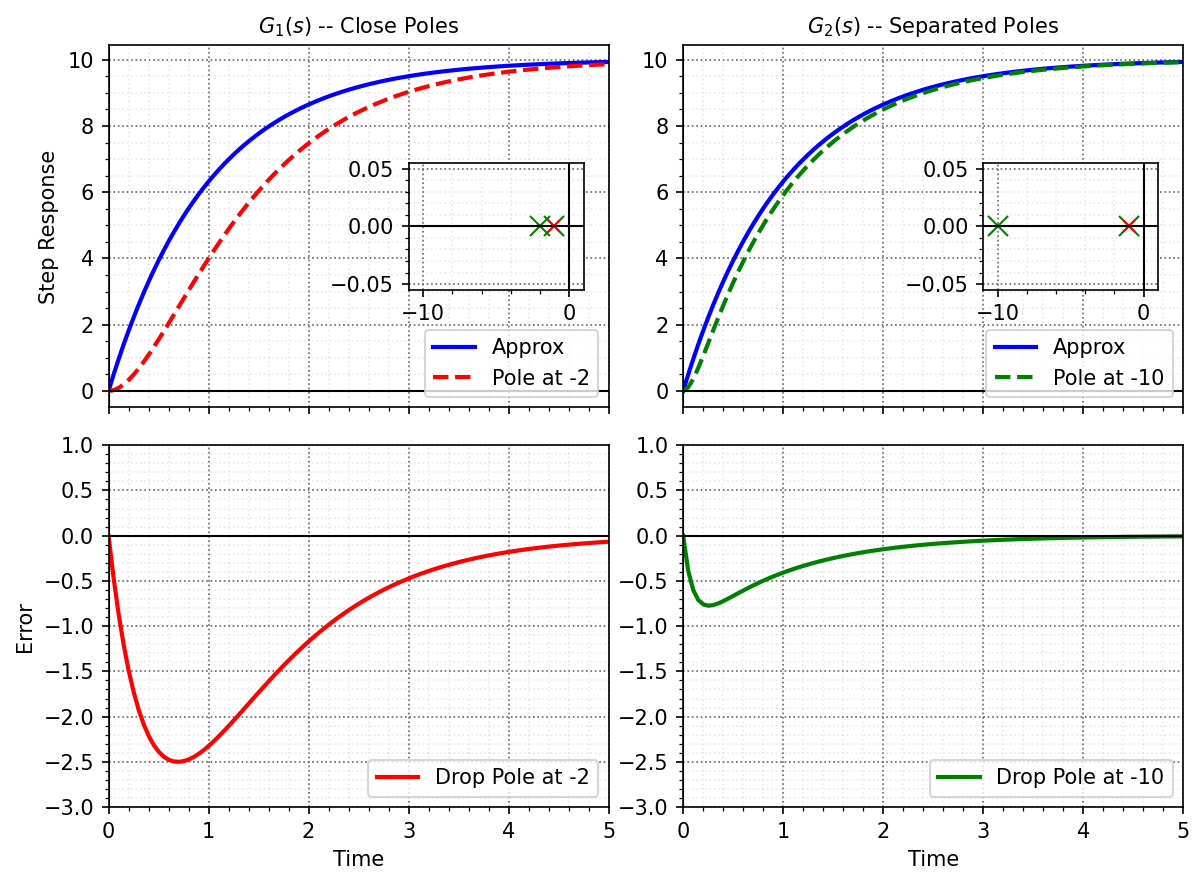

In [110]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
fig, ax = plt.subplots(2, 2, figsize=(8, 6), dpi=150, sharex=True, constrained_layout=False)

# Step responses
yap, t = cmat.step(P, 5)
y1,  t = cmat.step(P1, t)
y2,  t = cmat.step(P2, t)

# Main plots
ax[0][0].plot(t, yap, 'b', label='Approx')
ax[0][1].plot(t, yap, 'b', label='Approx')
ax[0][0].plot(t, y1, 'r--', label='Pole at -2')
ax[0][1].plot(t, y2, 'g--', label='Pole at -10')
ax[1][0].plot(t, y1 - yap, 'r-', label='Drop Pole at -2')
ax[1][1].plot(t, y2 - yap, 'g-', label='Drop Pole at -10')

ax[0][0].set_ylabel("Step Response")
ax[1][0].set_ylabel("Error")
ax[0][0].set_title("$G_1(s)$ -- Close Poles")
ax[0][1].set_title("$G_2(s)$ -- Separated Poles")
ax[1][0].set_ylim(-3, 1)
ax[1][1].set_ylim(-3, 1)

# -------- Insets (FIXED) --------

# Inset for G1(s)
ax2 = inset_axes(
    ax[0][0],
    width="35%", height="35%",
    loc="right",
    borderpad=1.2
)
ax2.plot(np.real(P1.poles()), np.imag(P1.poles()), 'x', ms=10, color='green')
ax2.plot(np.real(P.poles()),  np.imag(P.poles()),  'x', ms=6,  color='red')
ax2.set_xlim((-11, 1))
bm.nicegrid(ax2)

# Inset for G2(s)
ax3 = inset_axes(
    ax[0][1],
    width="35%", height="35%",
    loc="right",
    borderpad=1.2
)
ax3.plot(np.real(P2.poles()), np.imag(P2.poles()), 'x', ms=10, color='green')
ax3.plot(np.real(P.poles()),  np.imag(P.poles()),  'x', ms=6,  color='red')
ax3.set_xlim((-11, 1))
bm.nicegrid(ax3)

# Formatting
for x in range(2):
    ax[1][x].set_xlabel("Time")
    for y in range(2):
        ax[x][y].legend(loc=4)
        bm.nicegrid(ax[x][y], 6)

plt.tight_layout()
plt.savefig("./figs/DP_Ex1.pdf", bbox_inches="tight")
plt.show()

## Compute impact terms on Slide 5-6

In [111]:
from sympy import symbols, inverse_laplace_transform, integrate, oo, simplify

# Define the Laplace variable and the transfer function with complex poles
s = symbols('s')
R, p, q, t, z = symbols('R p q t z', positive=True)
omega = symbols('omega', positive=True)
PP = {}
PP['real'] =  R / (s + p)
PP['dreal'] = R / (s + p)**2
PP['treal'] = R / (s + p)/(s + q)
PP['zreal'] = R * (s + z) / (s + p)/(s + q)
PP['CC'] = R / ((s + p)**2 + omega**2)
PP['zCC'] = R * (s+z) / ((s + p)**2 + omega**2)

for P in PP.values():
    print(P)
    # Compute the inverse Laplace transform (impulse response)
    impulse_response = inverse_laplace_transform(P, s, t)

    # Integrate the impulse response from 0 to infinity
    #integrated_response = simplify(integrate(impulse_response, (t, 0, oo)))
    integrated_square_response = simplify(integrate(impulse_response**2, (t, 0, oo)))

    print(f"Impulse response: {impulse_response}")
    #print(f"Integrated response from 0 to infinity: {integrated_response}")
    print(f"Integrated square response from 0 to infinity: {integrated_square_response}")
    print('\n')

R/(p + s)
Impulse response: R*exp(-p*t)
Integrated square response from 0 to infinity: R**2/(2*p)


R/(p + s)**2
Impulse response: R*t*exp(-p*t)
Integrated square response from 0 to infinity: R**2/(4*p**3)


R/((p + s)*(q + s))
Impulse response: R*(exp(-t*(p*q - q**2)/(p - q))/(p - q) - exp(-t*(p**2 - p*q)/(p - q))/(p - q))
Integrated square response from 0 to infinity: nan


R*(s + z)/((p + s)*(q + s))
Impulse response: R*((p - z)*exp(-t*(p**2 - p*q)/(p - q))/(p - q) + (-q + z)*exp(-t*(p*q - q**2)/(p - q))/(p - q))
Integrated square response from 0 to infinity: nan


R/(omega**2 + (p + s)**2)
Impulse response: R*exp(-p*t)*sin(omega*t)/omega
Integrated square response from 0 to infinity: R**2/(4*p*(omega**2 + p**2))


R*(s + z)/(omega**2 + (p + s)**2)
Impulse response: R*(exp(-p*t)*cos(omega*t) + (-p + z)*exp(-p*t)*sin(omega*t)/omega)
Integrated square response from 0 to infinity: R**2*(omega**2 + p**2 + z**2)/(4*p*(omega**2 + p**2))




In [112]:
# Show partial fraction expansion
from sympy import apart, N, Symbol
S = Symbol('S')

def tf2sympy(P, S=Symbol('S')):
    P_sympy_n = P_sympy_d = 0
    for kk, vv in enumerate(P.num[0][0][::-1]):
        P_sympy_n += vv * S**kk
    for kk, vv in enumerate(P.den[0][0][::-1]):
        P_sympy_d += vv * S**kk
    return P_sympy_n/P_sympy_d

def pfe_print(P, DCmatch=False, printout=False, Nred=2):
    # Case 1: P is already a SymPy expression
    if isinstance(P, sp.Expr):
        P_sympy = sp.simplify(P)
        P_sympy_pfe = sp.apart(P_sympy)
        if printout:
            print("P (SymPy)")
            display(sp.N(P_sympy, 4))
            print("P PFE")
            display(sp.N(P_sympy_pfe, 4))
        return P_sympy, None

    # Case 2: P is a python-control TransferFunction
    P_sympy = tf2sympy(P)
    P_sympy_pfe = sp.apart(P_sympy)

    P_red = cm.balred(P)
    if DCmatch:
        P_red *= P.dcgain() / P_red.dcgain()

    P_sympy_red = tf2sympy(P_red)
    P_sympy_red_pfe = sp.apart(P_sympy_red)

    if printout:
        print("P PFE")
        display(sp.N(P_sympy_pfe, 4))
        print("P Balred")
        display(sp.N(P_sympy_red_pfe, 4))

    return P_sympy_red, P_red

In [113]:
P1 = cm.normalize_tf(P1)
cm.show_tf_latex(P1,factor=True,label="P_1",show=True)
Ps1_red, P1_red = pfe_print(P1, printout=True)

<IPython.core.display.Math object>

Order not specified - selected   2
Using Method 0
P PFE


20.0/(S + 1.0) - 10.0/(0.5*S + 1.0)

P Balred


20.0/(S + 1.0) - 10.0/(0.5*S + 1.0)

In [114]:
P2 = cm.normalize_tf(P2)
cm.show_tf_latex(P2,factor=True,label="P_2",show=True)
Ps2_red, P2_red = pfe_print(P2, printout=True)

<IPython.core.display.Math object>

Order not specified - selected   1
Using Method 0
P PFE


11.11/(S + 1.0) - 1.111/(0.1*S + 1.0)

P Balred


7.881/(1.0*S + 0.7319)

## Example 2 (more complex)

In [115]:
s = ct.tf('s')
# slow system
P = 1/(s+1)
# add faster system
P1 = 10**2/(s**2+2*s + 10**2) * P
P2 = P*1/(s/10+1)*1/(s/11+1)

In [116]:
P1 = cm.normalize_tf(P1)
cm.show_tf_latex(P1,factor=True,label="P_1",show=True)
Ps1_red, P1_red = pfe_print(P1, printout=True)

<IPython.core.display.Math object>

Order not specified - selected   3
Using Method 0
P PFE


-0.0101*(S + 1.0)/(0.01*S**2 + 0.02*S + 1.0) + 1.01/(S + 1.0)

P Balred


-0.0101*(S + 1.0)/(0.01*S**2 + 0.02*S + 1.0) + 1.01/(S + 1.0)

In [117]:
P2 = cm.normalize_tf(P2)
cm.show_tf_latex(P2,factor=True,label="P_2",show=True)
Ps2_red, P2_red = pfe_print(P2, printout=True)

<IPython.core.display.Math object>

Order not specified - selected   2
Using Method 0
P PFE


1.222/(S + 1.0) - 1.222/(0.1*S + 1.0) + 1.0/(0.09091*S + 1.0)

P Balred


-0.8763*(0.0277*S - 1.0)/(0.1601*S**2 + 1.0*S + 0.8848)

### Plot responses to compare

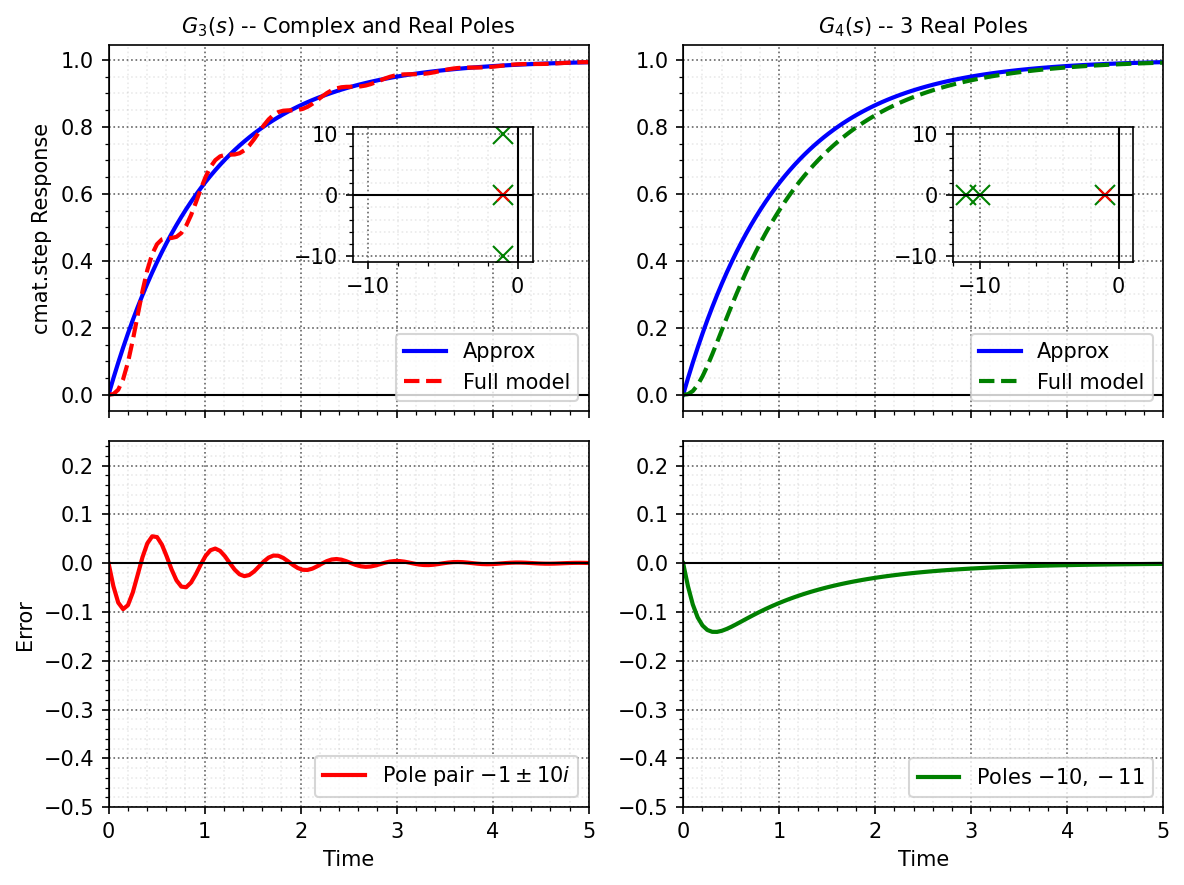

In [118]:
fig, ax = plt.subplots(2,2,figsize=(8, 6),dpi=150,sharex = True)
yap,t = cmat.step(P,5)
y1,t = cmat.step(P1,t)
y2,t = cmat.step(P2,t)

ax[0][0].plot(t,yap,'b',label='Approx')
ax[0][1].plot(t,yap,'b',label='Approx')
ax[0][0].plot(t,y1,'r--',label=r'Full model')
ax[0][1].plot(t,y2,'g--',label='Full model')
ax[1][0].plot(t,y1-yap,'r-',label=r'Pole pair $-1\pm 10i$')
ax[1][1].plot(t,y2-yap,'g-',label=r'Poles $-10,-11$')
ax[0][0].set_ylabel("cmat.step Response")
ax[1][0].set_ylabel("Error")
ax[0][0].set_title("$G_3(s)$ -- Complex and Real Poles")
ax[0][1].set_title("$G_4(s)$ -- 3 Real Poles")

left, bottom, width, height = [0.3, 0.7, 0.15, 0.15]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.figure.set_facecolor('w')
ax2.plot(np.real(P1.poles()),np.imag(P1.poles()), 'x', ms=10, color='green')
ax2.plot(np.real(P.poles()),np.imag(P.poles()), 'x', ms=6, color='red')
ax2.set_xlim((-11,1))
ax2.set_ylim((-11,11))

left, bottom, width, height = [0.8, 0.7, 0.15, 0.15]
ax3 = fig.add_axes([left, bottom, width, height])
ax3.figure.set_facecolor('w')
ax3.plot(np.real(P2.poles()),np.imag(P2.poles()), 'x', ms=10, color='green')
ax3.plot(np.real(P.poles()),np.imag(P.poles()), 'x', ms=6, color='red')
ax3.set_xlim((-12,1))
ax3.set_ylim((-11,11))
bm.nicegrid(ax2)
bm.nicegrid(ax3)

[ax[1][x].set_ylim((-.5,.25)) for x in range(2)]
[ax[x][y].legend(loc=4) for x in range(2) for y in range(2)]
[bm.nicegrid(ax[x][y],6)  for x in range(2) for y in range(2)]
[ax[1][x].set_xlabel("Time") for x in range(2)]
plt.savefig("./figs/DP_Ex2.pdf", dpi=300)
plt.show()

In [136]:
def print_pfe_info(P):
    r, p, k = residue(P.num[0][0], P.den[0][0])
    cm.pretty_row_print(r,"Residues:")
    cm.pretty_row_print(p,"Poles:")
    cm.pretty_row_print(k,"Direct term:")
    return r, p, k

print_pfe_info(P1)
print("")
print_pfe_info(P2)    


Residues:0.101, 8.990
Poles:-1.000, -10.000
Direct term:

Residues:1.048, -0.095
Poles:-1.000, -2.000
Direct term:


(array([   1.048,   -0.095]),
 array([  -1.000,   -2.000]),
 array([], dtype=float64))

## Example 3 (with Zeros)

In [137]:
s = ct.tf('s')
# slow
P = 1/(s+1)
# add faster with a zero
P1 = (s/1.1+1)/(s/10+1) * P
P2 = (s/2.1+1)/(s/2+1) * P

yap,t = cmat.step(P,5)
y1,t = cmat.step(P1,t)
y2,t = cmat.step(P2,t)

In [138]:
Ps1_red, P1_red = pfe_print(P1, printout=True)

Order not specified - selected   1
Using Method 0
P PFE


0.101/(S + 1.0) + 0.899/(0.1*S + 1.0)

P Balred


0.935/(0.1039*S + 1.0)

In [142]:
Ps2_red, P2_red = pfe_print(P2, printout=True)
cm.show_tf_latex(cm.balred(P2,1),label="P_2^{red}",show=True)

Order not specified - selected   1
Using Method 0
P PFE


1.048/(S + 1.0) - 0.04762/(0.5*S + 1.0)

P Balred


0.9636/(1.0*S + 0.9584)

Using Method 0


<IPython.core.display.Math object>

In [143]:
from sympy import latex
ss = Symbol('s')
sP = 1/(ss+1)
sP1 = (ss/1.1+1)/(ss/10+1) * sP
sP2 = (ss/2.1+1)/(ss/2+1) * sP

Ps1_red, _ = pfe_print(sP1, printout=True)
Ps2_red, _ = pfe_print(sP2, printout=True)

P (SymPy)


(9.091*s + 10.0)/((s + 1.0)*(s + 10.0))

P PFE


0.101/(s + 1.0) + 0.899/(0.1*s + 1.0)

P (SymPy)


(0.9524*s + 2.0)/((s + 1.0)*(s + 2.0))

P PFE


1.048/(s + 1.0) - 0.04762/(0.5*s + 1.0)

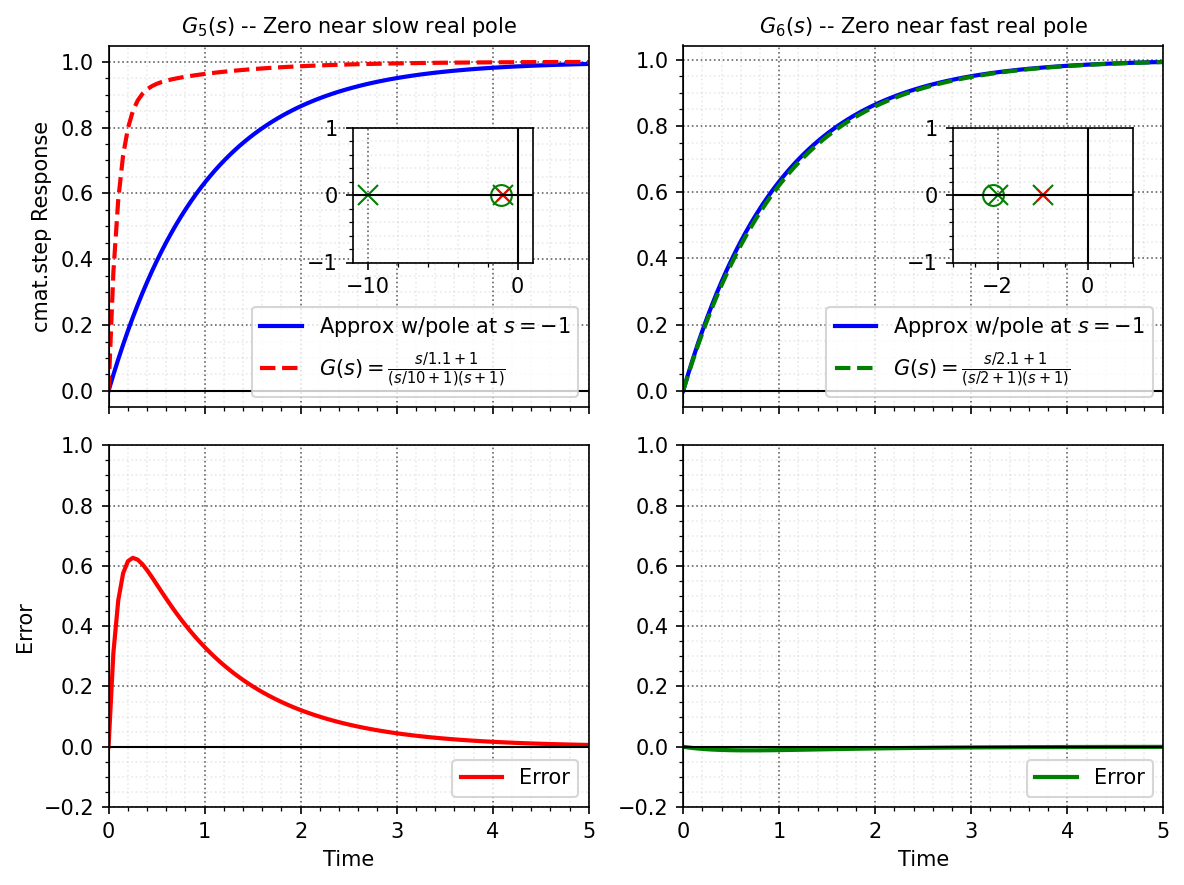

In [124]:
fig, ax = plt.subplots(2,2,figsize=(8, 6),dpi=150,sharex = True)

[ax[0][x].plot(t,yap,'b',label=r'Approx w/pole at $s=-1$') for x in range(2)]
ax[0][0].plot(t,y1,'r--',label=r'$G(s) = \frac{s/1.1+1}{(s/10+1)(s+1)}$')
ax[0][1].plot(t,y2,'g--',label=r'$G(s) = \frac{s/2.1+1}{(s/2+1)(s+1)}$')
ax[1][0].plot(t,y1-yap,'r-',label=r'Error')
ax[1][1].plot(t,y2-yap,'g-',label=r'Error')
ax[0][0].set_ylabel("cmat.step Response")
ax[1][0].set_ylabel("Error")

left, bottom, width, height = [0.3, 0.7, 0.15, 0.15]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.figure.set_facecolor('w')
ax2.plot(np.real(P1.poles()),np.imag(P1.poles()), 'x', ms=10, color='green')
ax2.plot(np.real(P1.zeros()),np.imag(P1.zeros()), 'o', markerfacecolor='none', ms=10, color='green')
ax2.plot(np.real(P.poles()),np.imag(P.poles()), 'x', ms=6, color='red')
ax2.set_xlim((-11,1))
ax2.set_ylim((-1,1))
ax[0][0].set_title("$G_5(s)$ -- Zero near slow real pole")
ax[0][1].set_title("$G_6(s)$ -- Zero near fast real pole")

left, bottom, width, height = [0.8, 0.7, 0.15, 0.15]
ax3 = fig.add_axes([left, bottom, width, height])
ax3.figure.set_facecolor('w')
ax3.plot(np.real(P2.poles()),np.imag(P2.poles()), 'x', ms=10, color='green')
ax3.plot(np.real(P2.zeros()),np.imag(P2.zeros()), 'o', markerfacecolor='none', ms=10, color='green')
ax3.plot(np.real(P.poles()),np.imag(P.poles()), 'x', ms=6, color='red')
ax3.set_xlim((-3,1))
ax3.set_ylim((-1,1))
bm.nicegrid(ax2)
bm.nicegrid(ax3)

[ax[1][x].set_ylim((-.2,1)) for x in range(2)]
[ax[x][y].legend(loc=4) for x in range(2) for y in range(2)]
[bm.nicegrid(ax[x][y],6)  for x in range(2) for y in range(2)]
[ax[1][x].set_xlabel("Time") for x in range(2)]
plt.savefig("./figs/DP_Ex3.pdf", dpi=300)
plt.show()

## Analysis of the process of model reduction/balancing

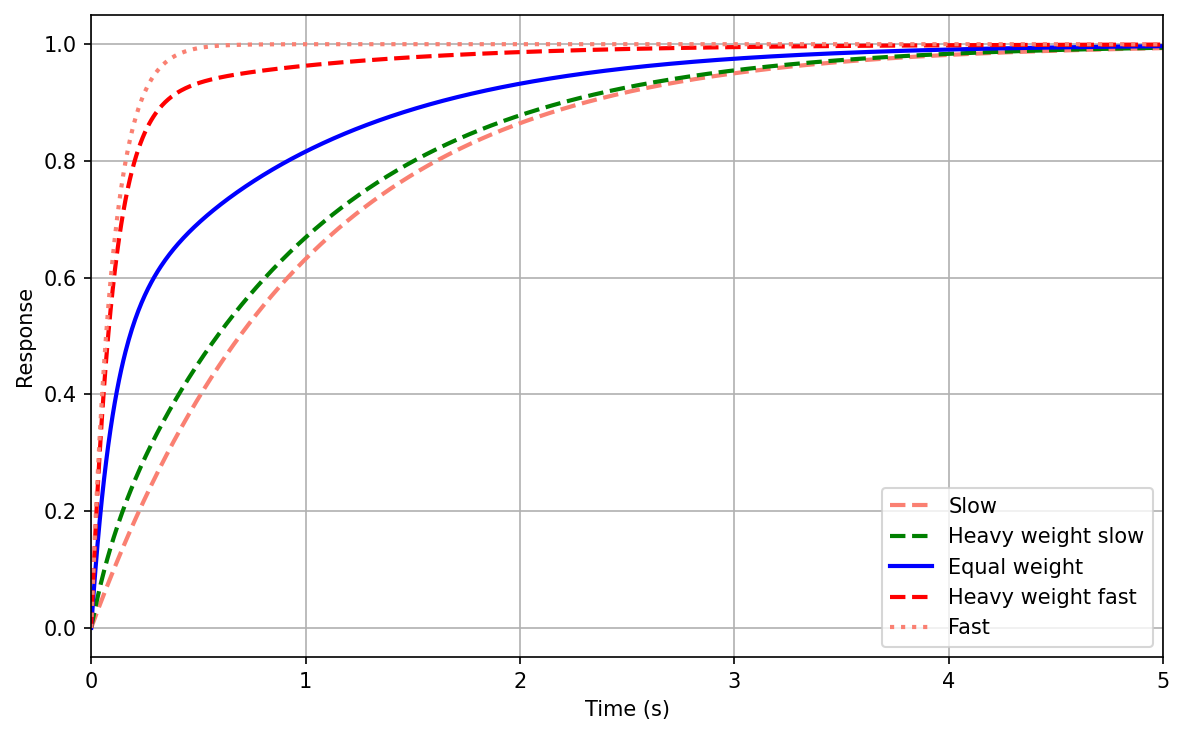

In [153]:
s = ct.tf('s')
# slow
Pslow = 1/(s/1+1)
Pfast = 1/(s/10+1)

weight = 10

# Various combinations of the slow and fast dynamics
P11 = 1/2*Pslow + 1/2*Pfast
P12 = 1/weight*Pslow + (weight-1)/weight*Pfast
P21 = (weight-1)/weight*Pslow + 1/weight*Pfast

t = np.linspace(0,5,1000)
y11,t = cmat.step(P11,t)
y12,t = cmat.step(P12,t)
y21,t = cmat.step(P21,t)
yslow,t = cmat.step(Pslow,t)
yfast,t = cmat.step(Pfast,t)

fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,sharex = True)
plt.plot(t,yslow,'--',c='salmon',label='Slow')
plt.plot(t,y21,'g--',label='Heavy weight slow')
plt.plot(t,y11,'b',label='Equal weight')
plt.plot(t,y12,'r--',label='Heavy weight fast')
plt.plot(t,yfast,':',c='salmon',label='Fast')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Response')
plt.show()

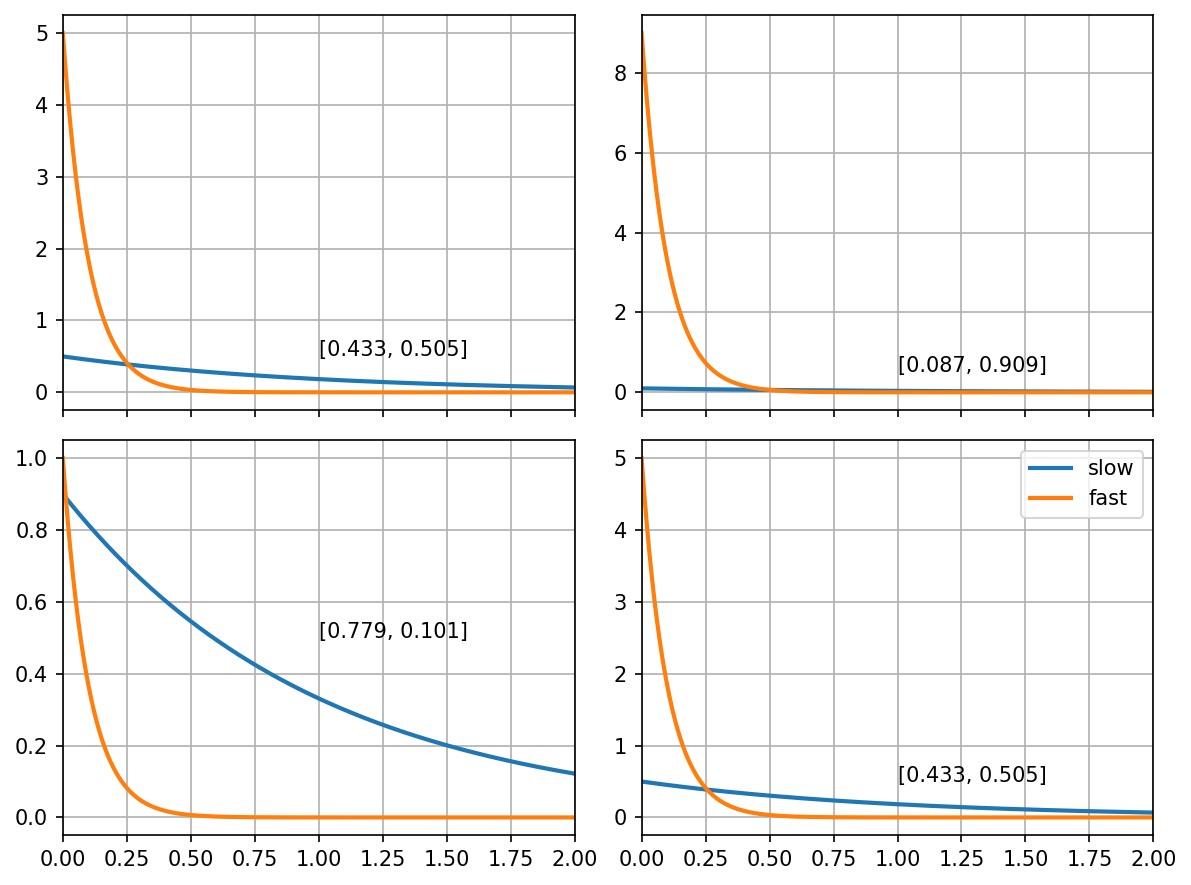

In [126]:
weight = 10
w1 = [1/2, 1/weight, (weight-1)/weight, 1/2]
w2 = [1/2, (weight-1)/weight, 1/weight, 1/2]
tt = np.linspace(0,2,1000)

fig, ax = plt.subplots(2,2,figsize=(8, 6),dpi=150,sharex = True)
for ii in range(2):
    for jj in range(2):
        PPslow = w1[2*ii+jj]*Pslow
        PPfast = w2[2*ii+jj]*Pfast
        tt,y_imp_slow = ct.impulse_response(PPslow,T=tt)
        tt,y_imp_fast = ct.impulse_response(PPfast,T=tt)
        y_imp_slow_integrated = np.round(np.cumsum(y_imp_slow)[-1] * (tt[1] - tt[0]),3)
        y_imp_fast_integrated = np.round(np.cumsum(y_imp_fast)[-1] * (tt[1] - tt[0]),3)
        ax[ii][jj].plot(tt, y_imp_slow)
        ax[ii][jj].plot(tt, y_imp_fast)
        ax[ii][jj].text(1,0.5,[y_imp_slow_integrated,y_imp_fast_integrated])
plt.legend(['slow', 'fast'])
plt.show()

## Consider impact of DCmatch

In [168]:
cm.show_tf_latex(P11,label="P_{11}",show=True)
P11_red = cm.balred(P11,DCmatch=True,order=1)
cm.show_tf_latex(P11_red,label="P_{11}^{red}",show=True)
P11_red_nm = cm.balred(P11,DCmatch=False,order=1)
cm.show_tf_latex(P11_red_nm,label="P_{11}^{red~ nm}",show=True)

<IPython.core.display.Math object>

Using Method 0


<IPython.core.display.Math object>

Using Method 0


<IPython.core.display.Math object>

In [169]:
h = ct.tf([1, 11, 36, 26],[1, 14.6, 74.96, 153.7, 99.65])
cm.show_tf_latex(h,show=True)
print(f"DC gain of original is {h.dcgain():.4f}")

hbal = cm.near_zero(cm.balred(h,DCmatch=True,order = 1),Tol=1e-4)
cm.show_tf_latex(hbal,show=True,label="G_{red}^{dc~match}")
print(f"DC gain of balanced with DC match is {hbal.dcgain():.4f}")

hbal_nm = cm.near_zero(cm.balred(h,DCmatch=False,order = 1),Tol=1e-4)
cm.show_tf_latex(hbal_nm,show=True)
print(f"DC gain of balanced without DC match is {hbal_nm.dcgain():.4f}")


<IPython.core.display.Math object>

DC gain of original is 0.2609
Using Method 0


<IPython.core.display.Math object>

DC gain of balanced with DC match is 0.2609
Using Method 0


<IPython.core.display.Math object>

DC gain of balanced without DC match is 0.2788


[1.0000000000000002, 1.0684393783433996]


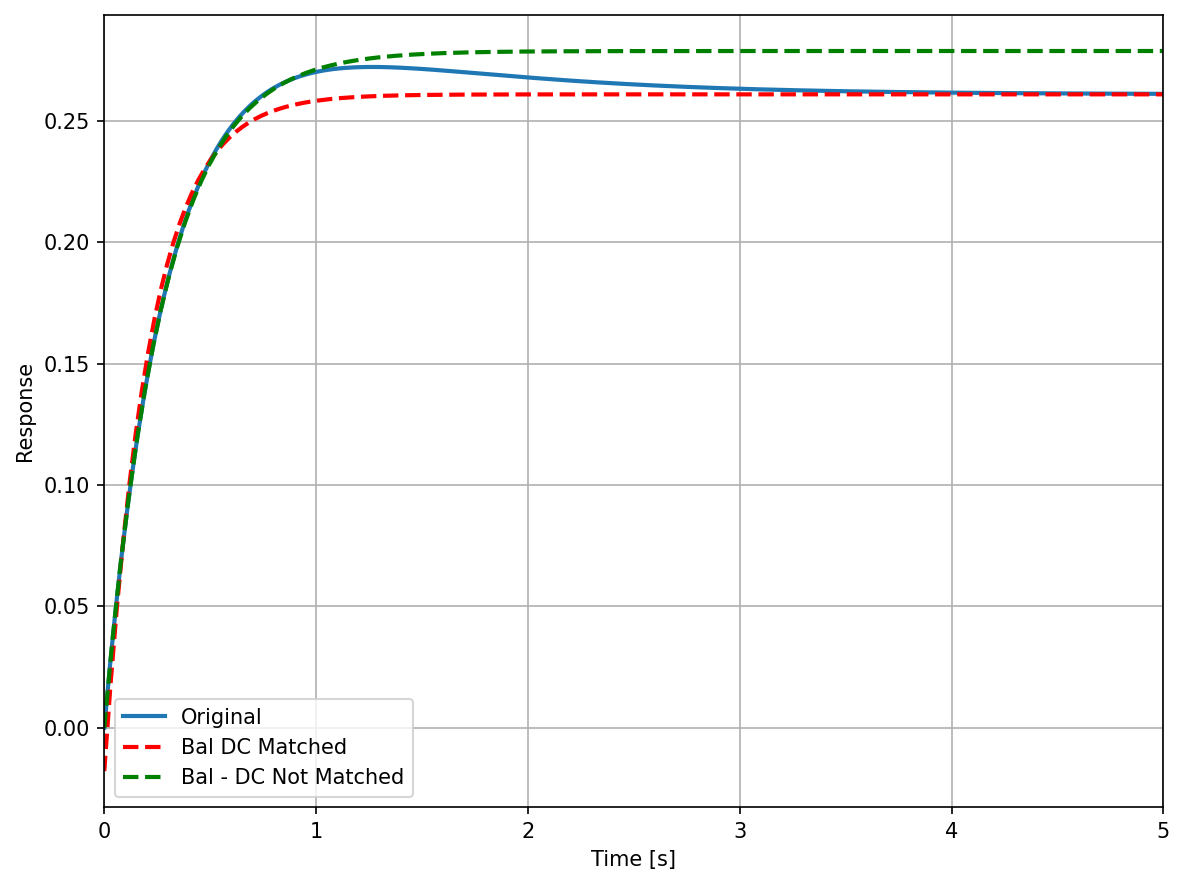

In [172]:
y,ty = cmat.step(h,5)
ybal,tbal = cmat.step(hbal,5)
ybal_nm,tbal_nm = cmat.step(hbal_nm,5)

fig, ax = plt.subplots(1,figsize=(8, 6),dpi=150,sharex = True)
plt.plot(ty,y,label='Original')
plt.plot(tbal,ybal,'r--',label='Bal DC Matched')
plt.plot(tbal_nm,ybal_nm,'g--',label='Bal - DC Not Matched')
plt.legend()
plt.xlabel("Time [s]")
plt.ylabel("Response")
g1 = float(hbal.dcgain()/h.dcgain())
g2 = float(hbal_nm.dcgain()/h.dcgain())
ax.text(0.05, 0.95, f"DC ratios: {g1:.3f}, {g2:.3f}", transform=ax.transAxes, va='top')
plt.show()

In [134]:
from sympy import symbols, inverse_laplace_transform, integrate, oo, simplify

# Define the Laplace variable and the transfer function with complex poles
s = symbols('s')
p, q, t, z = symbols('p q t z', positive=True)
omega = symbols('omega', positive=True)
PP = {}
PP['real'] = 1 / (s/p + 1)
PP['dreal'] = 1 / (s/p + 1)**2
PP['treal'] = 1 / (s/p + 1)/(s/q+1)
PP['zreal'] = (s/z+1) / (s/p + 1)/(s/q + 1)
PP['CC'] = (p**2+omega**2) / ((s + p)**2 + omega**2)

for P in PP.values():
    print(P)
    # Compute the inverse Laplace transform (impulse response)
    impulse_response = inverse_laplace_transform(P, s, t)

    # Integrate the impulse response from 0 to infinity
    #integrated_response = simplify(integrate(impulse_response, (t, 0, oo)))
    integrated_square_response = simplify(integrate(impulse_response**2, (t, 0, oo)))

    print(f"Impulse response: {impulse_response}")
    #print(f"Integrated response from 0 to infinity: {integrated_response}")
    print(f"Integrated square response from 0 to infinity: {integrated_square_response}")
    print('\n')

1/(1 + s/p)
Impulse response: p*exp(-p*t)
Integrated square response from 0 to infinity: p/2


(1 + s/p)**(-2)
Impulse response: p**2*t*exp(-p*t)
Integrated square response from 0 to infinity: p/4


1/((1 + s/p)*(1 + s/q))
Impulse response: p*q*exp(-t*(p*q - q**2)/(p - q))/(p - q) - p*q*exp(-t*(p**2 - p*q)/(p - q))/(p - q)
Integrated square response from 0 to infinity: p*q/(2*(p + q))


(s/z + 1)/((1 + s/p)*(1 + s/q))
Impulse response: (-p*q**2 + p*q*z)*exp(-t*(p*q*z - q**2*z)/(p*z - q*z))/(p*z - q*z) + (p**2*q - p*q*z)*exp(-t*(p**2*z - p*q*z)/(p*z - q*z))/(p*z - q*z)
Integrated square response from 0 to infinity: p*q*(p*q + z**2)/(2*z**2*(p + q))


(omega**2 + p**2)/(omega**2 + (p + s)**2)
Impulse response: (omega**2 + p**2)*exp(-p*t)*sin(omega*t)/omega
Integrated square response from 0 to infinity: (omega**2 + p**2)/(4*p)


